# Adaptive multi-fidelity MOBO- on a reproducible example

Note that the dummy functions are **not** the CFD data used in the paper, but can be provided on request.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from mf_mobo_demo import (
    DummyCFDSimulator, quality_control, run_demo
)


## 1. Black-box simulator

The optimiser supplies a design vector and a fidelity level.  The simulator
returns the expensive objective `f1`, the exact objective `f2`, and numerical
diagnostics.


In [8]:
sim = DummyCFDSimulator(dimension=2)

x_good = np.array([0.45, 0.50])
x_bad  = np.array([0.95, 0.90])  # deliberately difficult for the dummy LF model

lf_good = sim.evaluate(x_good, "LF")
lf_bad  = sim.evaluate(x_bad, "LF")
hf_bad  = sim.evaluate(x_bad, "HF")

print("LF, normal region:", lf_good)
print("\nLF, difficult region:", lf_bad)
print("\nHF at the same difficult design:", hf_bad)


LF, normal region: SimulationResult(x=array([0.45, 0.5 ]), fidelity='LF', f1=0.21458861344333252, f2=0.45, diagnostics={'kp_stability': 0.0007, 'flux_imbalance': 0.00025})

LF, difficult region: SimulationResult(x=array([0.95, 0.9 ]), fidelity='LF', f1=0.24571979074681055, f2=0.95, diagnostics={'kp_stability': 0.002935555555555555, 'flux_imbalance': 0.001274642857142857})

HF at the same difficult design: SimulationResult(x=array([0.95, 0.9 ]), fidelity='HF', f1=0.16728958310727152, f2=0.95, diagnostics={'kp_stability': 0.0003, 'flux_imbalance': 0.0002})


## 2. Numerical-quality gate

For LF, the demo applies the same thresholds used in the paper:
`Kp stability <= 2e-3` and `flux imbalance <= 1e-3`.
A failed LF result is escalated to HF and the failed LF is not trusted as an
ordinary LF observation.


In [9]:
for label, result in [("normal LF", lf_good), ("difficult LF", lf_bad)]:
    passed, checks = quality_control(result)
    print(label, "passed:", passed, checks)

print("\nIf the difficult LF fails, the sequential optimiser charges the LF attempt")
print("and evaluates the same design at HF; the failed LF is not trusted.")


normal LF passed: True {'kp_stability': True, 'flux_imbalance': True}
difficult LF passed: False {'kp_stability': False, 'flux_imbalance': False}

If the difficult LF fails, the sequential optimiser charges the LF attempt
and evaluates the same design at HF; the failed LF is not trusted.


## 3. EHF cost

The normalised costs are `c_L=1` and `c_H=14.5`, so an LF evaluation costs
`1/14.5` EHF and an HF evaluation costs `1` EHF.

The sequential loop terminates on remaining **EHF budget**, not on a fixed
number of BO iterations.


In [10]:
cL, cH = 1.0, 14.5
print("LF EHF cost =", cL/cH)
print("HF EHF cost =", cH/cH)


LF EHF cost = 0.06896551724137931
HF EHF cost = 1.0


## 4. Run Adaptive MF

At each iteration, the code fits the recursive multi-fidelity GP and evaluates
the closed-form augmented-Tchebycheff EI.  The selected design--fidelity pair
maximises `EI/c_m` over the candidate set.


In [11]:
adaptive = run_demo("adaptive", dimension=2, budget_ehf=12.0, seed=4)
adaptive.summary()


{'iterations': 70,
 'realised_ehf': 11.965517241379294,
 'requested_hf_fraction': 0.05714285714285714,
 'actual_hf_fraction': 0.05714285714285714,
 'escalations': 0,
 'n_trusted_lf': 70,
 'n_hf': 7}

In [12]:
# Show the first few sequential decisions.
for r in adaptive.records[:8]:
    print(
        f"it={r.iteration:02d} requested={r.requested_fidelity} "
        f"actual={r.actual_fidelity} escalated={r.escalated} "
        f"EHF={r.cumulative_ehf:.3f}"
    )


it=00 requested=LF actual=LF escalated=False EHF=3.483
it=01 requested=LF actual=LF escalated=False EHF=3.552
it=02 requested=LF actual=LF escalated=False EHF=3.621
it=03 requested=LF actual=LF escalated=False EHF=3.690
it=04 requested=LF actual=LF escalated=False EHF=3.759
it=05 requested=LF actual=LF escalated=False EHF=3.828
it=06 requested=LF actual=LF escalated=False EHF=3.897
it=07 requested=LF actual=LF escalated=False EHF=3.966


## 5. Compare the three fidelity policies

- Adaptive MF: fidelity selected using `EI/c_m`
- Fixed MF: `LF, LF, LF, HF, ...`
- HF-only: `HF, HF, HF, ...`

This comparison is only illustrative because the objective functions are
synthetic.


In [13]:
summaries = {}
for strategy in ["adaptive", "fixed", "hf_only"]:
    opt = run_demo(strategy, dimension=2, budget_ehf=12.0, seed=4)
    summaries[strategy] = opt.summary()
summaries


{'adaptive': {'iterations': 70,
  'realised_ehf': 11.965517241379294,
  'requested_hf_fraction': 0.05714285714285714,
  'actual_hf_fraction': 0.05714285714285714,
  'escalations': 0,
  'n_trusted_lf': 70,
  'n_hf': 7},
 'fixed': {'iterations': 30,
  'realised_ehf': 11.999999999999995,
  'requested_hf_fraction': 0.23333333333333334,
  'actual_hf_fraction': 0.23333333333333334,
  'escalations': 0,
  'n_trusted_lf': 27,
  'n_hf': 10},
 'hf_only': {'iterations': 8,
  'realised_ehf': 11.413793103448276,
  'requested_hf_fraction': 1.0,
  'actual_hf_fraction': 1.0,
  'escalations': 0,
  'n_trusted_lf': 4,
  'n_hf': 11}}

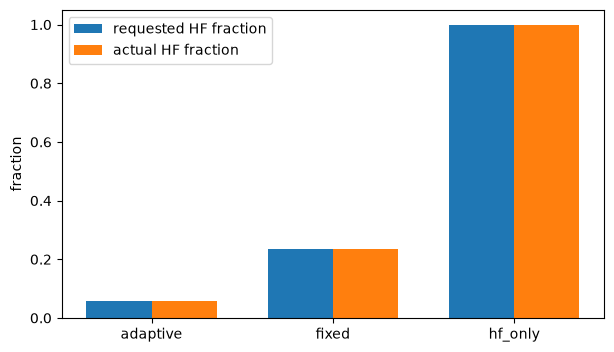

In [14]:
names = list(summaries)
req = [summaries[n]["requested_hf_fraction"] for n in names]
act = [summaries[n]["actual_hf_fraction"] for n in names]

xpos = np.arange(len(names))
width = 0.36
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(xpos-width/2, req, width, label="requested HF fraction")
ax.bar(xpos+width/2, act, width, label="actual HF fraction")
ax.set_xticks(xpos, names)
ax.set_ylabel("fraction")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()
